In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
import pathlib
from pyometiff import OMETIFFReader
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv
from sklearn.cluster import KMeans

from sklearn.ensemble import IsolationForest
from sklearn import linear_model

img_fpath = pathlib.Path("./test.tif")
reader = OMETIFFReader(fpath=img_fpath)
img_array, metadata, xml_metadata = reader.read()
img_array.shape

key not found 'NoneType' object has no attribute 'iter'
Key not found: 'NoneType' object has no attribute 'iter'


(1000, 520, 696)

In [2]:
select = 1
th = 30

if select == 0:
    # 1. Rango
    var_im = np.max(img_array, axis=0) - np.min(img_array, axis=0)
    th = 100

if select == 1:
    # 2. Varianza
    var_im = np.var(img_array, axis=0)  # Poblacional
    th = 120

if select == 2:
    # 2. Varianza
    var_im = np.var(img_array, axis=0, ddof=1)  # Muestral
    th = 200

if select == 3:
    # 3. Desviación estándar
    th = 12
    var_im = np.std(img_array, axis=0)  # Poblacional

if select == 4:
    # 3. Desviación estándar
    th = 5
    var_im = np.std(img_array, axis=0, ddof=1)  # Muestral

if select == 5:
    # 4. Coeficiente de variación
    th = 5
    var_im = np.std(img_array, axis=0, ddof=1)  # Muestral
    media = np.mean(img_array, axis=0)
    var_im = (var_im / media) * 100

if select == 6:
    th = 20
    # 5. Rango intercuartílico (IQR)
    q1 = np.percentile(img_array, 25, axis=0)
    q3 = np.percentile(img_array, 75, axis=0)
    var_im = q3 - q1

In [3]:
from skimage.filters import unsharp_mask
result_1 = unsharp_mask(var_im, radius=20, amount=1)
kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
image = cv.filter2D(var_im, -1, kernel)

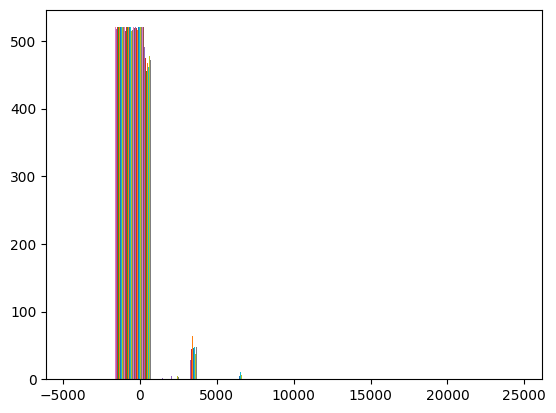

In [4]:
histogram = plt.hist(image)

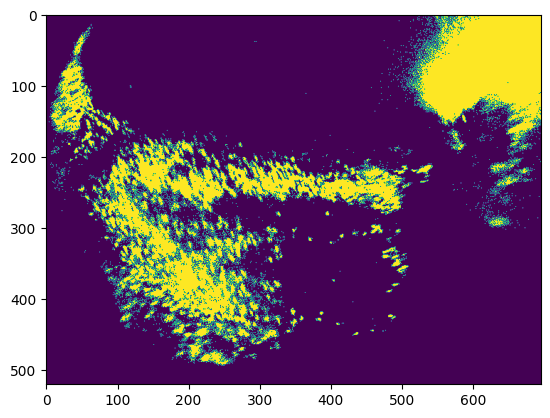

In [5]:
deconvolved_RL2 = np.reshape(image, (image.shape[0] * image.shape[1]))
res_labels = [int(deconvolved_RL2[i] > th) for i in range(len(deconvolved_RL2))]
res_labels = np.reshape(res_labels, (image.shape[0], image.shape[1]))
plt.imshow(res_labels)
plt.show()

In [6]:
def candidate_neighbors(node):
    return [(node[0] + 1, node[1]), (node[0], node[1] + 1), (node[0] + 1, node[1] + 1),
           (node[0] - 1, node[1]), (node[0], node[1] - 1), (node[0] - 1, node[1] - 1),
           (node[0] + 1, node[1] - 1), (node[0] - 1, node[1] + 1)]

def neighboring_groups(nodes):
    remain = set(nodes)
    while len(remain) > 0:
        visit = [remain.pop()]
        group = []
        while len(visit) > 0:
            node = visit.pop()
            group.append(node)
            for nb in candidate_neighbors(node):
                if nb in remain:
                    remain.remove(nb)
                    visit.append(nb)
        yield group

# nodes = [1, 22, 5, 20, 3, 4, 21, 2]
# print(list(neighboring_groups(nodes)))

In [7]:
pixels = []
for i in range(res_labels.shape[0]):
    for j in range(res_labels.shape[1]):
        if res_labels[i][j] == True:
            pixels.append((i, j))

In [8]:
res_clusters = list(neighboring_groups(pixels))
len(res_clusters)

2123

In [9]:
len(res_clusters[0])

3595

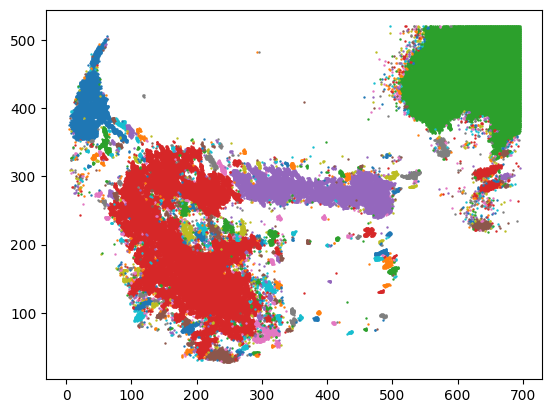

In [10]:
#plotting the results:
fig = plt.figure()
for cl in res_clusters:
    plt.scatter(np.array(cl)[:, 1], np.array(var_im).shape[0] - np.array(cl)[:, 0], marker='o', s=(72./fig.dpi)**2)
plt.show()

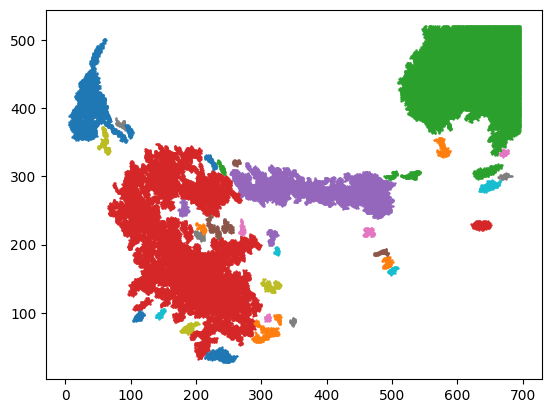

In [11]:
#plotting the results:
min_size = 50
max_cluster = 0
sel_cluster = 0
fig = plt.figure()
clusters_min_size = []
final_cl = []
for cl in res_clusters:
    if len(cl) >= min_size:
        clusters_min_size.append(cl)
        plt.scatter(np.array(cl)[:, 1], np.array(var_im).shape[0] - np.array(cl)[:, 0], marker='o', s=(72./fig.dpi)**2)
plt.show()

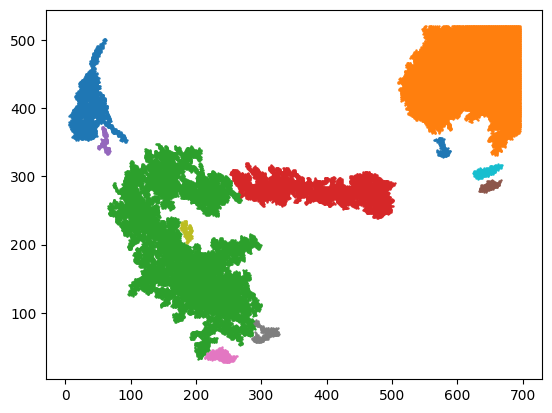

In [12]:
#plotting the results:
min_size = 20
max_size = 200
max_cluster = 0
sel_cluster = 0
fig = plt.figure()
clusters_min_size = []
final_cl = []
for cl in res_clusters:
    if max_size >= len(cl) >= min_size:
        final_cl.append(cl)
    elif len(cl) >= min_size:
        clusters_min_size.append(cl)
        plt.scatter(np.array(cl)[:, 1], np.array(var_im).shape[0] - np.array(cl)[:, 0], marker='o', s=(72./fig.dpi)**2)
plt.show()

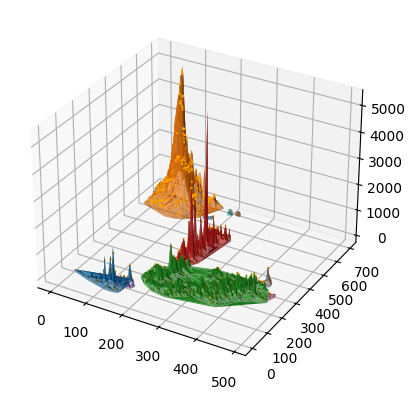

In [13]:
max_size = 0
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
show_peaks = True
all_peaks = []

for cl in clusters_min_size:

    z = []
    x = []
    y = []
    for i in range(len(cl)):
        z.append(var_im[cl[i]])
        x.append(cl[i][0])
        y.append(cl[i][1])
    z = np.array(z)
    y = np.array(y)
    x = np.array(x)

    clf = linear_model.SGDOneClassSVM(random_state=42, nu=0.131).fit(z.reshape(-1, 1))
    y_pred = clf.predict(z.reshape(-1, 1))
    y_res = [i for i, x in enumerate(list(y_pred)) if x == -1]
    min_x = min(x)
    max_x = max(x)
    min_y = min(y)
    max_y = max(y)
    min_x, max_x, min_y, max_y
    Z = np.zeros((max_x - min_x + 1, max_y - min_y + 1))
    for i in range(len(z)):
        Z[x[i] - min_x, y[i] - min_y] = z[i]
    # Calcular derivadas parciales numéricas
    dz_dx = np.gradient(Z, axis=1)  # Derivada parcial respecto a x
    dz_dy = np.gradient(Z, axis=0)  # Derivada parcial respecto a y

    peaks = []
    for i in range(1, Z.shape[0] - 1):       # Ignorar bordes
        for j in range(1, Z.shape[1] - 1):   # Ignorar bordes
            # Verificar cambio de signo en las derivadas
            if dz_dx[i, j - 1] > 0 and dz_dx[i, j] <= 0 and dz_dy[i - 1, j] > 0 and dz_dy[i, j] <= 0:
                if Z[i - 1, j] == 0 or Z[i + 1, j] == 0 or Z[i, j - 1] == 0 or Z[i, j + 1] == 0:
                    continue
                # Verificar si es un máximo local comparándolo con sus vecinos
                peaks.append((i + min_x, j + min_y, Z[i][j]))
                all_peaks.append((i + min_x, j + min_y, Z[i][j]))

    ax.plot_trisurf(x, y, z, linewidth=0.2, antialiased=True)
    if show_peaks:
        x_p = []
        y_p = []
        z_p = []
        for i in range(len(peaks)):
            x_p.append(peaks[i][0])
            y_p.append(peaks[i][1])
            z_p.append(peaks[i][2])
        ax.scatter(x_p, y_p, z_p, color='orange', s=(72./fig.dpi)**2)
plt.show()

In [14]:
# Calcular derivadas parciales
dz_dx = np.gradient(var_im, axis=1)
dz_dy = np.gradient(var_im, axis=0)

In [15]:
# Detectar picos usando cambio de signo en las derivadas, pero solo en puntos seleccionados
def find_peaks(Z, dz_dx, dz_dy, selected_points):
    peaks = []
    for i, j in selected_points:
        # Buscar si es un pico (máximo local)
        if dz_dx[i, j - 1] > 0 and dz_dx[i, j] <= 0 and dz_dy[i - 1, j] > 0 and dz_dy[i, j] <= 0:
            peaks.append((i, j))
    return peaks

In [16]:
# from tqdm.notebook import tqdm
# Asignar puntos seleccionados a los picos más cercanos
from scipy.spatial import distance
def assign_points_to_peaks(Z, peaks, selected_points):
    # Inicializar una lista para los conjuntos de puntos por pico
    peak_sets = {i: [] for i in range(len(peaks))}
    
    # Crear una matriz de etiquetas para asignar puntos a conjuntos
    peak_map = np.zeros_like(Z, dtype=int) - 1  # Matriz que guarda la etiqueta del pico más cercano
    gx = np.gradient(Z, axis=1)  # Derivada parcial respecto a x
    gy = np.gradient(Z, axis=0)  # Derivada parcial respecto a y
    
    # Etiquetar los picos con IDs únicos
    for label_id, (pi, pj) in enumerate(peaks):
        peak_map[pi, pj] = label_id  # Etiquetar los picos
    
    # Asignar los puntos seleccionados a sus picos más cercanos
    for i, j in selected_points:
        x, y = i, j
        seen = []
        while (x, y) not in seen and (x,y) not in peaks:  # Hasta llegar a un pico
            # Obtener dirección del gradiente descendente
            dx, dy = int(np.sign(gx[x, y])), int(np.sign(gy[x, y]))
            
            # Moverse en la dirección del gradiente descendente
            new_x, new_y = x + dx, y + dy
            if (0 <= new_x < Z.shape[0]) and (0 <= new_y < Z.shape[1]):
                seen.append((x, y))
                x, y = new_x, new_y
            else:
                break  # Salir si estamos en el borde
        min_dist = max(Z.shape[0], Z.shape[1])
        sel_peak = []
        for p in peaks:
            dst = math.dist(p, (x, y))
            if dst < min_dist:
                min_dist = dst
                sel_peak = p
        # Asignar el punto al conjunto del pico donde se llegó
        x, y = sel_peak
        peak_id = peak_map[x, y]
        peak_sets[peak_id].append((i, j))
    
    return peak_sets

  0%|          | 0/85 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

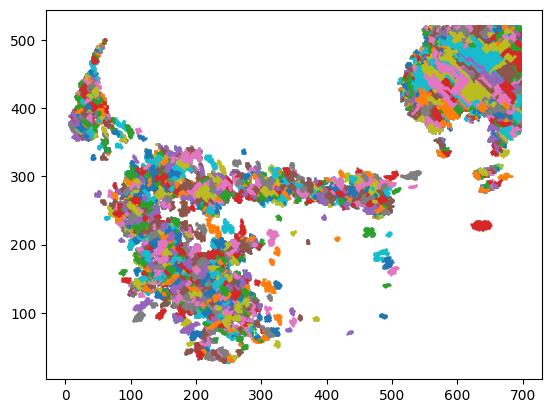

In [17]:
max_size = 0
import math
from tqdm.notebook import tqdm
# final_cl = []
for cl in tqdm(final_cl):
    plt.scatter(np.array(cl)[:, 1], np.array(var_im).shape[0] - np.array(cl)[:, 0], marker='o', s=(72./fig.dpi)**2)
for cl in tqdm(clusters_min_size):
    # print('CHECK')
    plt.scatter(np.array(cl)[:, 1], np.array(var_im).shape[0] - np.array(cl)[:, 0], marker='o', s=(72./fig.dpi)**2)

    peaks = find_peaks(var_im, dz_dx, dz_dy, cl)
    # print('CHECK PEAKS')
    # print(peaks)
    # region_labels = assign_points_to_peaks(var_im, peaks, cl)
    if len(peaks) > 0:
        peak_sets = assign_points_to_peaks(var_im, peaks, cl)
        # print(peak_sets)
        # print('CHECK points')
        for peak_id, points in peak_sets.items():
            points_x = [np.array(var_im).shape[0] - i for i, j in points]
            points_y = [j for i, j in points]
            plt.scatter(points_y, points_x, label=f'Conjunto {peak_id + 1}', s=(72./fig.dpi)**2)
            final_cl.append(points)
    else:
        final_cl.append(cl)

In [18]:
len(final_cl)

1465

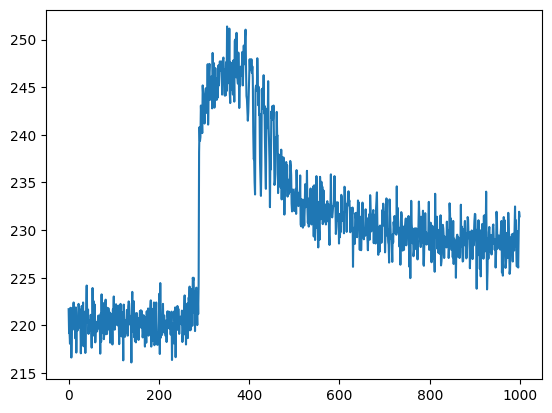

In [19]:
select_cluster = 2
final_array = np.array(final_cl[select_cluster])
sel_data_final = img_array[:, final_array[:,0], final_array[:,1]]
sel_data_final_mean = np.mean(sel_data_final, axis=1)
plt.plot(np.array(range(len(sel_data_final_mean))).reshape(-1, 1), sel_data_final_mean)
plt.show()